# Tutorial for working with the DESI MWS VAC DR1

Here we briefly demonstrate how to use the Milky Way Survey (MWS) Value Added Catalogue (VAC) for 
DESI Data Release 1.

The data that will be used here can be downloaded from: 
https://data.desi.lbl.gov/public/dr1/vac/dr1/mws/iron

The overall description of the MWS VAC is given here:
https://data.desi.lbl.gov/doc/releases/dr1/vac/mws/

And the data-model is available here:
https://desi-mws-dr1-datamodel.readthedocs.io/

This repo has a bash file `downloader.sh` that fetches the public FITS files used for this tutorial into `data/`.

The full combined file is:
* `mwsall-pix-iron.fits` which has all the MWS information for all the sources analysed by the MWS pipelines, as well as Gaia 
DR3 cross-match and DESI targeting information.

Most examples below read `slim.fits`, a local slim all-row catalogue derived from `mwsall-pix-iron.fits`, to keep memory use manageable.

The individual survey/program files: 
* `rvpix-main-bright.fits` -- these are the measurements by the RV pipeline of the sources in the main program, bright survey.
* `sppix-main-bright.fits` -- these are the measurements by the SP pipeline of the sources in the main program, bright survey.

Table with individual exposures measurements
* `rvpix_exp-sv3-bright.fits` -- these are the measurements by the RV pipeline from individual DESI exposures for the sv3 survey, bright program

And some individual files for stars in a given healpixel:
* `rvtab_coadd-main-bright-10813.fits` -- this is a table of measurements by the RV pipeline for sources in the main program, bright survey in healpixel 10813
* `rvmod_coadd-main-bright-10813.fits`

We also use one file with DESI spectra -- 
* `coadd-main-bright-10813.fits` -- From https://data.desi.lbl.gov/public/dr1/spectro/redux/iron/healpix/main/bright/108/10813/coadd-main-bright-10813.fits -- this is the file with the coadded spectra for the sources in the main program, bright survey in healpixel 10813.


###  MWS VAC DR1 paper 
The paper describing the MWS VAC is [Koposov+2026](https://ui.adsabs.harvard.edu/abs/2026OJAp....955260K/abstract), but see also [EDR VAC paper]( https://ui.adsabs.harvard.edu/abs/2024MNRAS.533.1012K/abstract) should provide adequate information on the contents of the VAC. 

Questions on this tutorial can be directed to Sergey Koposov (skoposov _AT_ ed _DOT_ ac _DOT_ uk)

In [1]:
import collections
import astropy.table as atpy
import astropy.coordinates as acoo
import astropy.io.fits as pyfits
import astropy.units as auni

import numpy as np

import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.colors as maco

%matplotlib inline

data_prefix = 'data/'

# Main catalogue

Here we read the combined table that contains most of the information. 
This table consists of several extensions that contain different information

1) RVTAB extension: RVSpecfit pipeline
2) SPTAB extension: FERRE pipeline
3) GAIA extension: Gaia parameters
4) FIBERMAP extension: table of targeting information
5) SCORES extension: spectra quality columns

Note, that when reading FITS tables with astropy tables we use `mask_invalid=False` option, due to the astropy/numpy 'peculiarities' when dealing with masked arrays.

** IMPORTANT ** 
If you ran the full download.sh script from this repo, youc comment out the second line 'fname =', and use the full catalogue, otherwise 
you will need to use the slimmed version of the catalogue.
If you have not downloaded any data, please download a small file from: https://drive.google.com/file/d/1oS4Hs-7p7MEd9JH6Ih6KdpQDwtXf3GaK/view?usp=sharing and place it in data/ folder

** IMPORTANT ** 

In [35]:
# Note these are pretty big tables

fname = data_prefix + 'mwsall_dr1.fits'
fname = data_prefix + 'mwsall_dr1_slim.fits'

RV_T = atpy.Table().read(fname,
                         'RVTAB',
                         mask_invalid=False)
SP_T = atpy.Table().read(fname,  'SPTAB',
                         mask_invalid=False)
FM_T = atpy.Table().read(fname, 'FIBERMAP',
                         mask_invalid=False)
# SC_T = atpy.Table().read(fname, 'SCORES',
#                         mask_invalid=False)

# Reading the Gaia cross-match table 

Since the Gaia cross-match table has all the Gaia columns, 
you may run out of memory if reading as an astropy table, so we read as a FITS table. 

In [3]:
# G_T = atpy.Table().read(data_prefix + 'mwsall-pix-iron.fits',
#                        'GAIA',
#                        mask_invalid=False)
G_T = pyfits.getdata(fname, 'GAIA')

# Selecting sources
Here we identify the subset of rows that

1) are primary (i.e. the best) observation if the object was observed in more than one survey/program
2) have no RVS warning flags
3) are classified as star by Redrock


In [4]:
main_sel = RV_T['PRIMARY'] & (RV_T['RVS_WARN'] == 0) & (RV_T['RR_SPECTYPE']
                                                        == 'STAR')

# Sky distribution

The spatial distribution of sources in the VAC

Text(0, 0.5, 'dec [deg]')

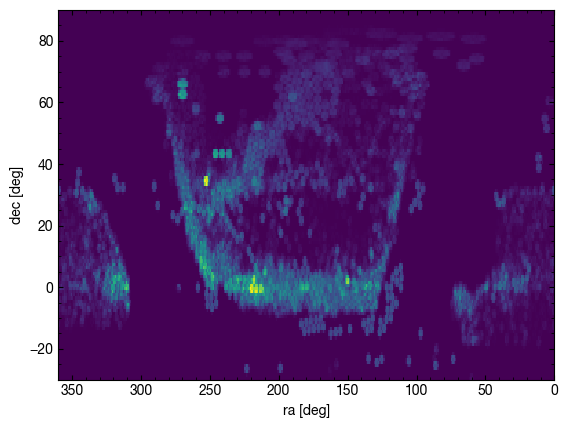

In [5]:
plt.hist2d(RV_T['TARGET_RA'][main_sel],
           RV_T['TARGET_DEC'][main_sel],
           bins=[360, 120],
           range=[[0, 360], [-30, 90]])
plt.xlabel('ra [deg]')
plt.xlim(360, 0)
plt.ylabel('dec [deg]')

# Multiple surveys/programs

The catalogue consists measurements of sources observed in  multiple DESI surveys and programs.

The survey with the most stars is `main`. This survey has three programs `bright` (with the most stars and where the Milky Survey is being executed), `dark` and `backup`. 

In [6]:
# Colour-magnitude distribution by survey/program
print('Surveys: ', np.unique(RV_T['SURVEY'][:]))
print('Programs: ', np.unique(RV_T['PROGRAM'][:]))

Surveys:   SURVEY
-------
    cmx
   main
special
    sv1
    sv2
    sv3
Programs:  PROGRAM
-------
 backup
 bright
   dark
  other


# Spatial distribution of objects in different surveys, programs

Here we look at several programs, surveys and look at spatial distribution of targets there


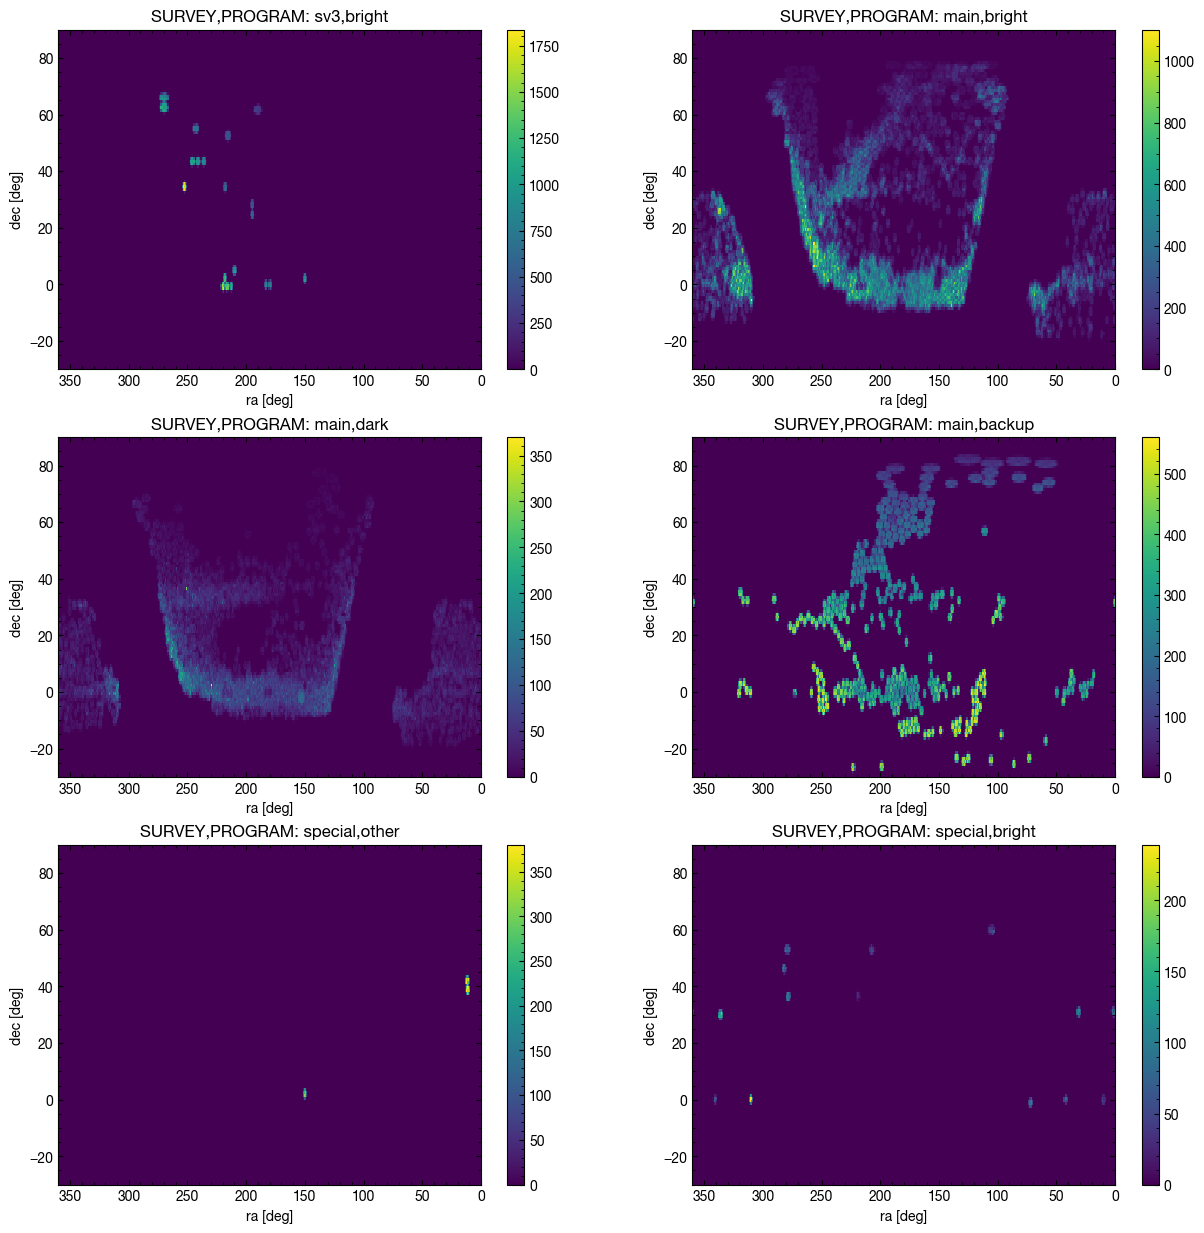

In [7]:
plt.figure(1, figsize=(15, 15))
cnt = 0
for survey, program in [('sv3', 'bright'), ('main', 'bright'),
                        ('main', 'dark'), ('main', 'backup'), ('special', 'other'),
                       ('special','bright')]:
    cur_sel = main_sel & (RV_T['SURVEY'] == survey) & (RV_T['PROGRAM']
                                                       == program)
    plt.subplot(3, 2, cnt + 1)
    plt.hist2d(RV_T['TARGET_RA'][cur_sel],
               RV_T['TARGET_DEC'][cur_sel],
               bins=[360, 120],
               range=[[0, 360], [-30, 90]])
    cnt += 1
    plt.title(f'SURVEY,PROGRAM: {survey},{program}')
    plt.xlabel('ra [deg]')
    plt.xlim(360, 0)
    plt.ylabel('dec [deg]')
    plt.colorbar()


# Photometry, targeting information

So far we mostly used the RVTAB extension, which has some basic source information as well 
as radial velocity and stellar parameters info from RV pipeline. 

If you need photometry and/or targeting information, it is mostly in the FIBERMAP extension.

Note that backup program of the main survey was *not* targeted using DESI/DECaLS(legacy) survey, 
therefore it does not have the DECALS flux columns populated. 
For all the rest we can use the FLUX_G, FLUX_R, FLUX_Z sources which are fluxes in g, r, z filters in 
nano-maggies (so they can be converted to magnitudes using 22.5-2.5*log10(flux))

You can see a description of columns in that extension here 
https://desi-mws-dr1-datamodel.readthedocs.io/en/latest/mwsall.html#hdu3


The columns in the fibermap extension:
<TableColumns names=('EBV','FLUX_G','FLUX_R','FLUX_Z','MASKBITS','PHOTSYS','DESI_TARGET','MWS_TARGET','SCND_TARGET')>
----


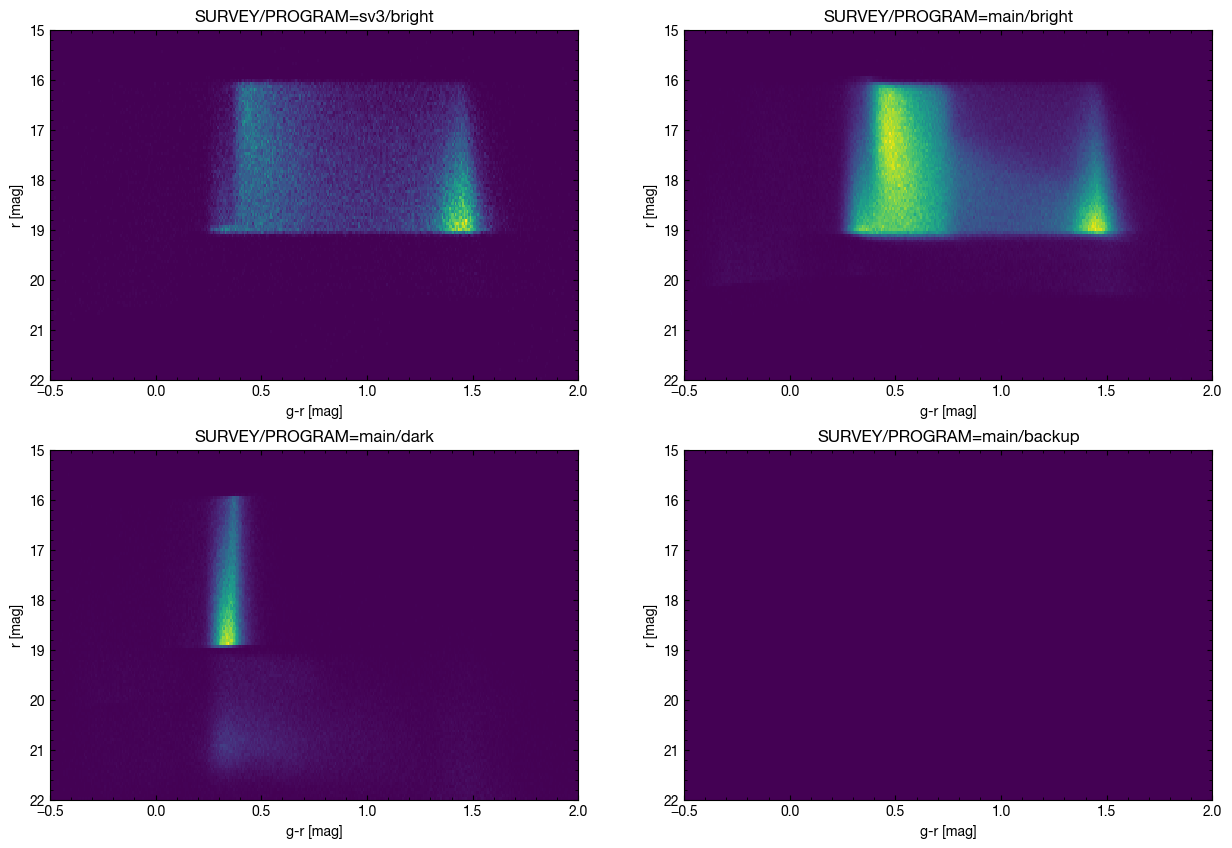

In [8]:
print('The columns in the fibermap extension:')
print((FM_T.columns))
print('----')
np.seterr(divide='ignore', invalid='ignore')
plt.figure(1, figsize=(15, 10))
cnt = 0
for survey, program in [('sv3', 'bright'), ('main', 'bright'),
                        ('main', 'dark'), ('main', 'backup')]:
    cur_sel = main_sel & (RV_T['SURVEY'] == survey) & (RV_T['PROGRAM']
                                                       == program)
    plt.subplot(2, 2, cnt + 1)
    plt.hist2d(-2.5 *
               np.log10(FM_T['FLUX_G'][cur_sel] / FM_T['FLUX_R'][cur_sel]),
               22.5 - 2.5 * np.log10(FM_T['FLUX_R'][cur_sel]),
               bins=[360, 120],
               range=[[-0.5, 2], [15, 22]])
    cnt += 1
    plt.title(f'SURVEY/PROGRAM={survey}/{program}')
    plt.xlabel('g-r [mag]')
    plt.ylim(22, 15)
    plt.ylabel('r [mag]')

# The colour magnitude distribution for backup survey

As mentioned above. The backup survey was targeted using Gaia photometry, and sources there are often brighter than the DECaLS saturation, as well as extend further than the DECaLS footprint. 
Therefore, it makes sense to look at backup program sources using Gaia magnitudes.

Gaia magnitudes are stored in the GAIA extension of the table. 

Note: that although there are Gaia magnitudes in the FIBERMAP extension as well, you should use the GAIA extension for the Gaia DR3 magnitudes.

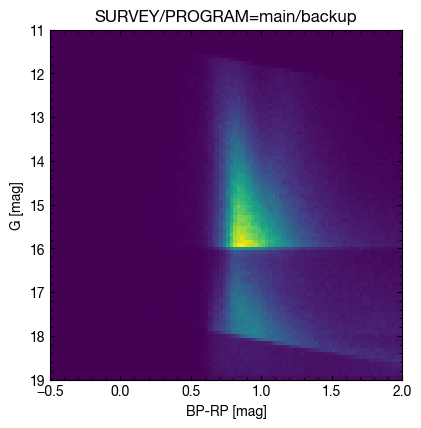

In [9]:
plt.figure(1, figsize=(10, 10))
cnt = 0
for survey, program in [('main', 'backup')]:
    cur_sel = main_sel & (RV_T['SURVEY'] == survey) & (RV_T['PROGRAM']
                                                       == program)
    plt.subplot(2, 2, cnt + 1)
    plt.hist2d(G_T['PHOT_BP_MEAN_MAG'][cur_sel] -
               G_T['PHOT_RP_MEAN_MAG'][cur_sel],
               G_T['PHOT_G_MEAN_MAG'][cur_sel],
               bins=[100, 100],
               range=[[-0.5, 2], [11, 19]])
    cnt += 1
    plt.title(f'SURVEY/PROGRAM={survey}/{program}')
    plt.xlabel('BP-RP [mag]')
    plt.ylim(19, 11)
    plt.ylabel('G [mag]')

# Different types of targets 

The targeting information is contained in the DESI_TARGET, MWS_TARGET, BGS_TARGET, SCND_TARGET columns that are bitmasks

The detailed information about those  is elsewhere, but here we show the main MWS object types
(see 
https://github.com/desihub/desitarget/blob/main/py/desitarget/data/targetmask.yaml
also, Koposov et al. 2024, Cooper et al. 2023, Myers et al. 2023)


    - [MWS_BROAD,           0, "Milky Way Survey magnitude limited bulk sample",         {obsconditions: BRIGHT}]
    - [MWS_WD,              1, "Milky Way Survey White Dwarf",                           {obsconditions: BRIGHT|DARK}]
    - [MWS_NEARBY,          2, "Milky Way Survey volume-complete ~100pc sample",         {obsconditions: BRIGHT}]
    # MWS BHBs
    - [MWS_BHB,             6, "Milky Way Survey Blue Horizontal Branch stars", {obsconditions: BRIGHT|DARK}]

    # Sub-classes of MWS_MAIN
    - [MWS_MAIN_BLUE,       8, "Milky Way Survey magnitude limited blue sample",              {obsconditions: BRIGHT}]
    - [MWS_MAIN_RED,        11, "Milky Way Survey magnitude limited red sample",              {obsconditions: BRIGHT}]

    # Standard stars based only on Gaia.
    - [GAIA_STD_FAINT,      33, "Standard stars for dark/gray conditions",   {obsconditions: DARK|BACKUP|TWILIGHT12|TWILIGHT18}]
    - [GAIA_STD_WD,         34, "White Dwarf stars",                         {obsconditions: DARK|BRIGHT|BACKUP|TWILIGHT12|TWILIGHT18}]
    - [GAIA_STD_BRIGHT,     35, "Standard stars for BRIGHT conditions",      {obsconditions: BRIGHT|BACKUP|TWILIGHT12|TWILIGHT18}]

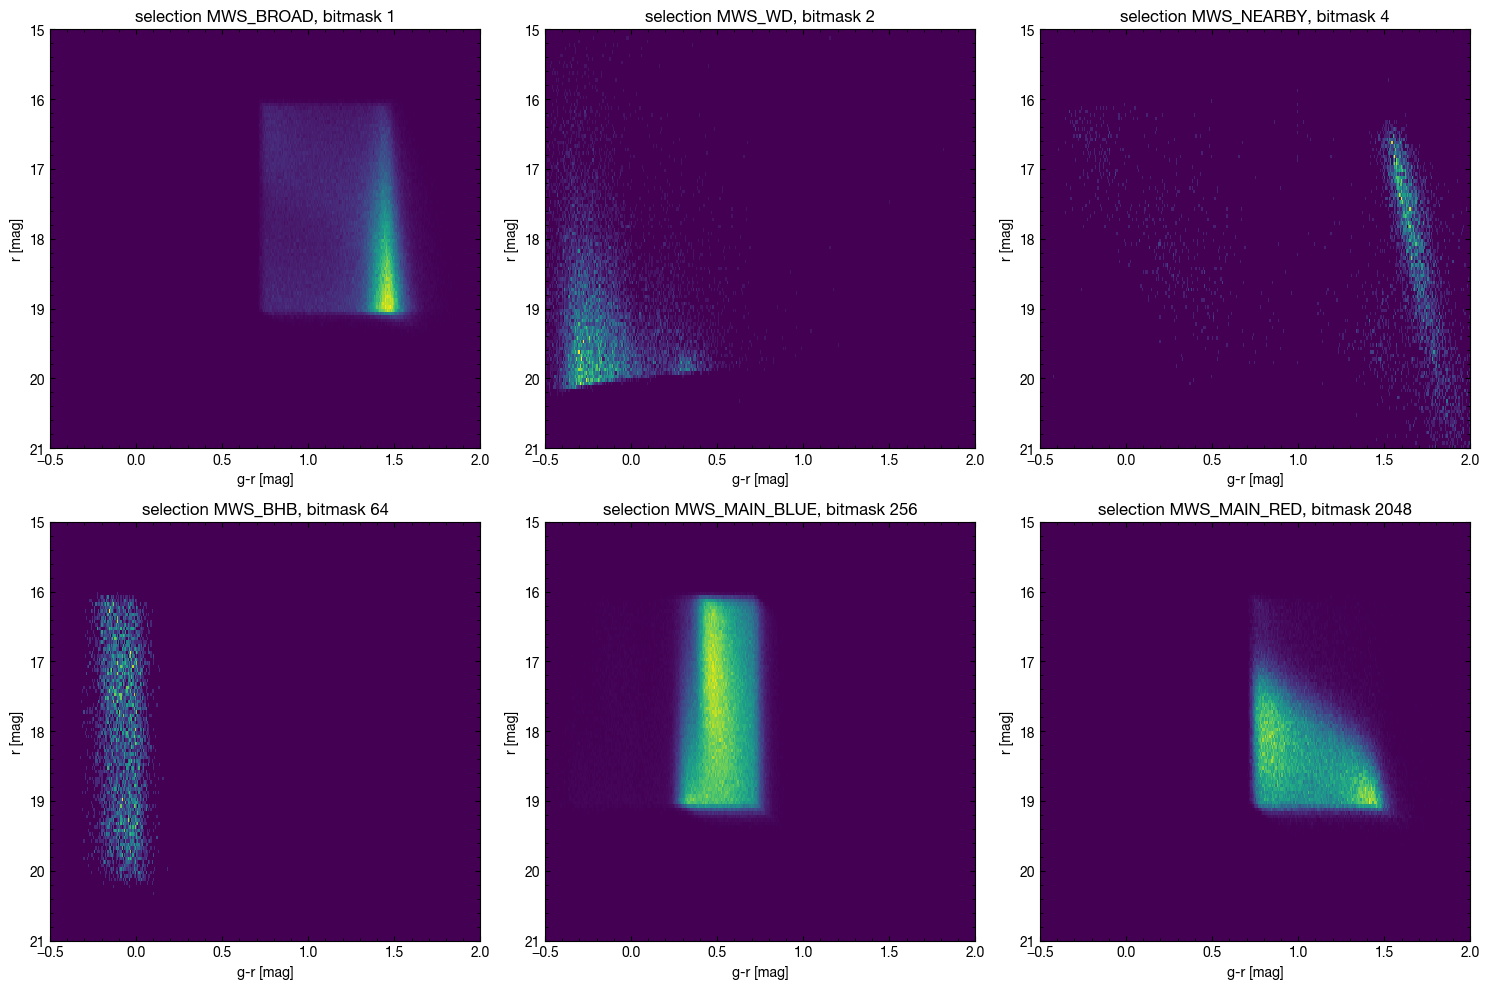

In [10]:
plt.figure(1, figsize=(15, 10))
cnt = 0
bitmasks = {
    'MWS_BROAD': 0,
    'MWS_WD': 1,
    'MWS_NEARBY': 2,
    'MWS_BHB': 6,
    'MWS_MAIN_BLUE': 8,
    'MWS_MAIN_RED': 11
}
survey, program = ('main', 'bright')

for curt, bit in bitmasks.items():
    objtype_sel = (FM_T['MWS_TARGET'] & (2**bit)) > 0
    cur_sel = objtype_sel & main_sel & (RV_T['SURVEY'] == survey) & (
        RV_T['PROGRAM'] == program)
    plt.subplot(2, 3, cnt + 1)
    plt.hist2d(-2.5 *
               np.log10(FM_T['FLUX_G'][cur_sel] / FM_T['FLUX_R'][cur_sel]),
               22.5 - 2.5 * np.log10(FM_T['FLUX_R'][cur_sel]),
               bins=[360, 120],
               range=[[-0.5, 2], [15, 21]])
    cnt += 1
    plt.title(f'selection {curt}, bitmask {2**bit}')
    plt.xlabel('g-r [mag]')
    plt.ylim(21, 15)
    plt.ylabel('r [mag]')
plt.tight_layout()

# MWS RR Lyrae 

The RR Lyrae were targeted as 'secondary targets'. To select them, rather than hardcoding the bits we 
use the desitarget package


Text(0, 0.5, 'dec')

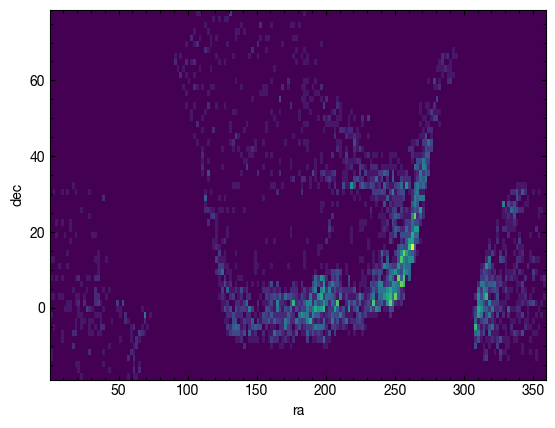

In [11]:
import desitarget.targetmask

main_targetmask = desitarget.targetmask

xind = (FM_T['SCND_TARGET'] & main_targetmask.scnd_mask['MWS_RR_LYRAE'])>0
plt.hist2d(RV_T['TARGET_RA'][xind],RV_T['TARGET_DEC'][xind],bins=[360//2,120//2]);
plt.xlabel('ra')
plt.ylabel('dec')

# Data filtering 

The catalogue contains some fraction of non-stellar objects.

They can be identified using Redrock spectral type.
There are 3 types, STAR,GALAXY and QSO

In [12]:
print (collections.Counter(RV_T['RR_SPECTYPE']))


Counter({'STAR': 4746247, 'GALAXY': 889728, 'QSO': 736632})


We can take a look at velocities for each of those classes. 

From the figure we see that that GALAXY still has some stellar contamination, while QSO does not.

Therefore a recommendation is to use either RR_SPECTYPE=STAR or 
RR_SPECTYPE!=QSO for more complete samples

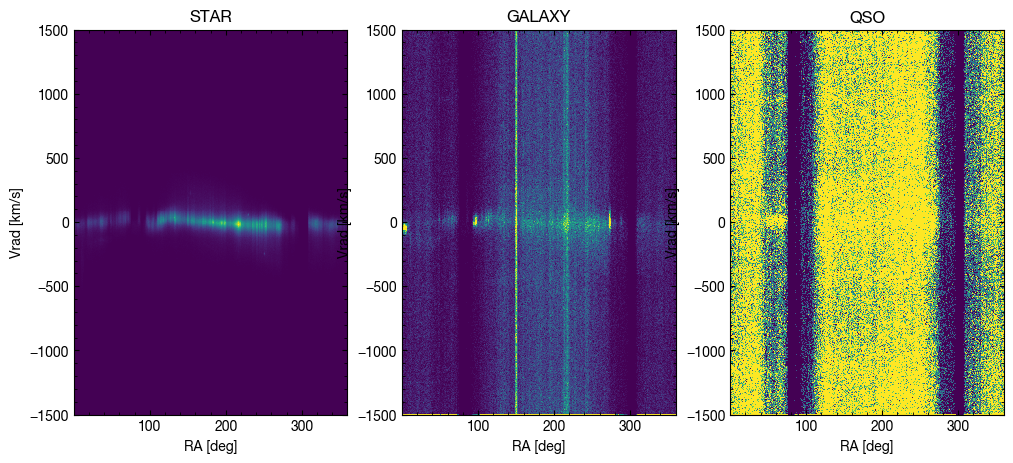

In [13]:
plt.figure(1,figsize=(12,5))
for i in range(3):
    plt.subplot(131+i)
    typ = ['STAR','GALAXY','QSO'][i]
    xind = RV_T['RR_SPECTYPE']==typ
    plt.hist2d(RV_T['TARGET_RA'][xind],RV_T['VRAD'][xind],bins=[400,400],vmax=[None,40,4][i]);
    plt.title(typ)
    plt.xlabel('RA [deg]')
    plt.ylabel('Vrad [km/s]')

# RVS_WARN

This is a flag from RVS indicating some issues. 
The bits correspond to 
* 1st bit ( 'CHISQ_WARN') is an alert based on the difference between chi-squares of best-fit 
and chi-squares of the fit when the model is just the continuum.
* 2nd bit (RV_WARN) is the the alert when the radial velocity is outside the range 
* 3rd bit (RVERR_WARN) is the alert when the radial velocity error is > 100 km/s
* 4th bit (RV_PARAM) is the alert when parameters are close to grid edges
* 5th bit (VSINI_WARN) is the alert when vsini is large
* 6th bit (BAD_SPECTRUM) there was an issue with the spectrum


Text(0.5, 0, 'VRAD [km/s]')

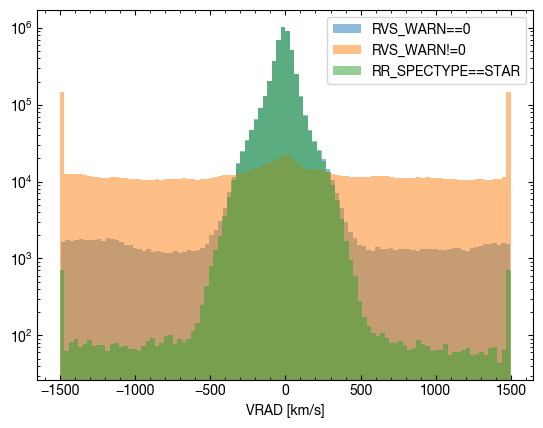

In [14]:
plt.hist(RV_T['VRAD'][RV_T["RVS_WARN"]==0],bins=100,alpha=.5,label='RVS_WARN==0');
plt.hist(RV_T['VRAD'][RV_T["RVS_WARN"]!=0],bins=100,alpha=.5,label='RVS_WARN!=0');
plt.hist(RV_T['VRAD'][RV_T["RR_SPECTYPE"]=='STAR'],bins=100,alpha=.5,label='RR_SPECTYPE==STAR');
plt.gca().set_yscale('log')
plt.legend()
plt.xlabel('VRAD [km/s]')

# Repeats/duplicates in combined catalogue

Since there are objects that have been observed many times you can find many rows with the same objects. 

Note the PRIMARY column at the end. The spectra with the highest SN in the red (R) arm are selected as primary.


In [15]:
RV_T[RV_T['TARGETID']==39627853679036228][['VRAD','SN_R','TARGETID','SURVEY','PROGRAM','PRIMARY']]

VRAD,SN_R,TARGETID,SURVEY,PROGRAM,PRIMARY
km / s,,,,,
float32,float32,int64,bytes7,bytes6,bool
78.10222,49.371124,39627853679036228,main,dark,False
80.18063,60.38141,39627853679036228,special,other,False
80.30129,37.73299,39627853679036228,sv1,bright,False
75.71252,117.39664,39627853679036228,sv1,dark,False
83.442986,155.84364,39627853679036228,sv1,other,True
83.05958,29.838003,39627853679036228,sv3,bright,False
82.51457,71.89173,39627853679036228,sv3,dark,False


Primary and secondary observations identification based on proximity (0.5" radius) and TARGETID. 
                                                                   
Therefore there are examples of sources with different TARGETID where one source is marked primary and another secondary.

Below is an example of the source observed in main/backup and main/bright under different targetid

In [16]:
RV_T[acoo.SkyCoord(RV_T['TARGET_RA']*auni.deg,
                   RV_T['TARGET_DEC']*auni.deg).separation(
    acoo.SkyCoord(24.83517729*auni.deg,30.86076520*auni.deg))<1*auni.arcsec]


VRAD,VRAD_ERR,VSINI,LOGG,LOGG_ERR,TEFF,TEFF_ERR,FEH,FEH_ERR,ALPHAFE,ALPHAFE_ERR,RVS_WARN,TARGET_RA,TARGET_DEC,TARGETID,SN_R,SUCCESS,RR_SPECTYPE,SURVEY,PROGRAM,PRIMARY
km / s,km / s,km / s,,,K,K,,,,,,,,,,,,,,
float32,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,int64,float64,float64,int64,float32,bool,bytes6,bytes7,bytes6,bool
-85.764755,0.4113848,0.01,4.1149325,0.037089814,6102.474,13.551256,-0.7540973,0.014267254,0.2587324,0.013657848,0,24.835177287392202,30.86076520304287,39628494149258099,73.14748,True,STAR,cmx,other,True
-85.123215,0.77435386,0.01,3.9606411,0.0723223,6035.6504,25.871727,-0.8271043,0.028287088,0.29269516,0.02760968,0,24.835177287392202,30.86076520304287,39637290242280307,39.56696,True,STAR,main,dark,False


# Stellar parameters

Here we look at surface gravity and effective temperature for stars the main/bright survey. 
We select signal-to-noise higher than 10 in the R arm.

Here we also look at parameters from both pipelines SP and RV

We also apply a VSINI<30 cut when using RV parameters 
and apply BESTGRID!='s_rdesi1 selection when using the SP parameters 

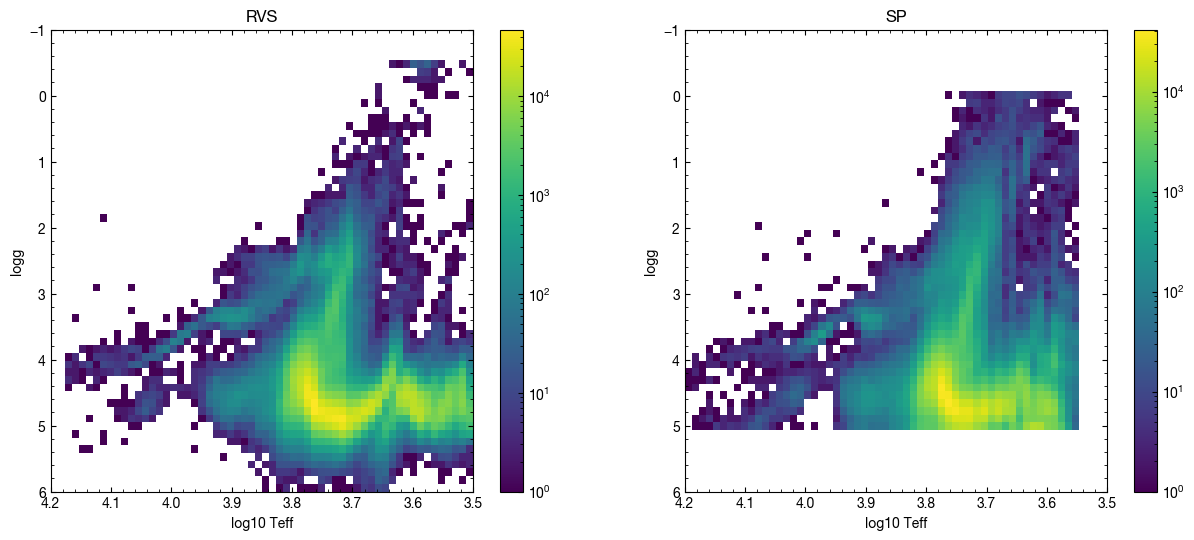

In [17]:
cur_sel = main_sel & (RV_T['SURVEY'] == 'main') & (
    RV_T['PROGRAM'] == 'bright') & (RV_T['SN_R'] > 10) & (RV_T['VSINI'] < 30)
plt.figure(1, figsize=(15, 6))
plt.subplot(121)
plt.hist2d(np.log10(RV_T['TEFF'][cur_sel]),
           RV_T['LOGG'][cur_sel],
           range=[[3.5, 4.2], [-1, 6]],
           bins=[60, 60],
           norm=maco.LogNorm())
plt.xlim(4.2, 3.5)
plt.ylim(6, -1)
plt.xlabel('log10 Teff')
plt.ylabel('logg')
plt.title('RVS')
plt.colorbar()

plt.subplot(122)
cur_sel = main_sel & (RV_T['SURVEY'] == 'main') & (
    RV_T['PROGRAM'] == 'bright') & (SP_T['SUCCESS'] == 1) & (SP_T['BESTGRID']
                                                             != 's_rdesi1')
plt.hist2d(np.log10(SP_T['TEFF'][cur_sel]),
           SP_T['LOGG'][cur_sel],
           range=[[3.5, 4.2], [-1, 6]],
           bins=[60, 60],
           norm=maco.LogNorm())
plt.xlim(4.2, 3.5)
plt.ylim(6, -1)
plt.xlabel('log10 Teff')
plt.ylabel('logg')
plt.title('SP')
plt.colorbar()

# Abundances 

[Fe/H] vs [a/Fe] distribution for RV and SP pipelines

We apply similar cuts as before and select stars with effective temperature between 4500 and 7000 K

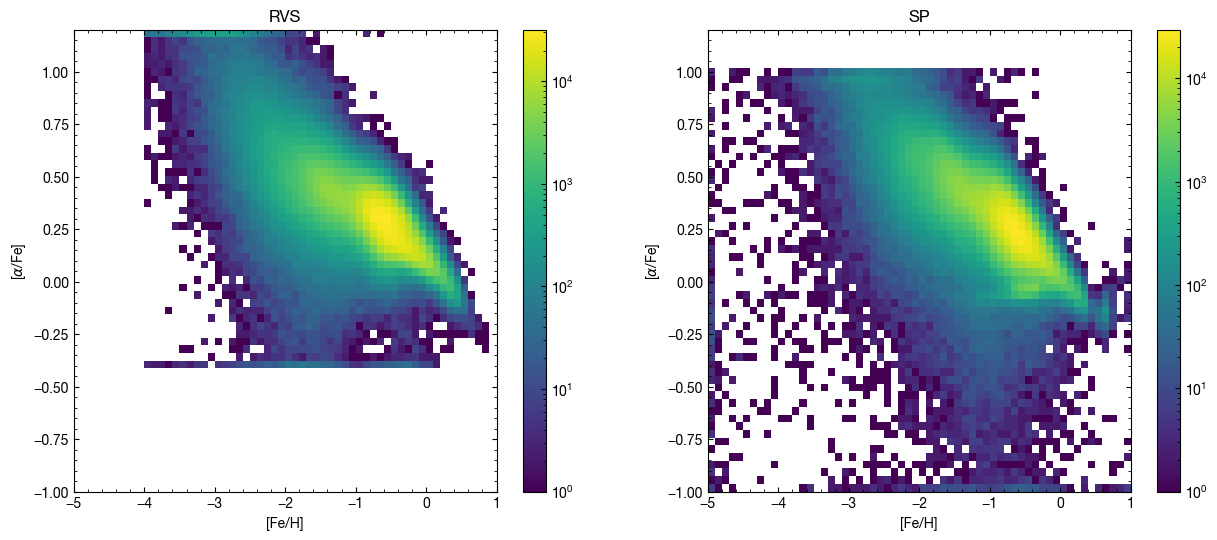

In [18]:
min_teff = 4500
max_teff = 7000

cur_sel = (main_sel & (RV_T['SURVEY'] == 'main') &
           (RV_T['PROGRAM'] == 'bright') & (RV_T['VSINI'] < 30) &
           (RV_T['TEFF'] > min_teff) & (RV_T['TEFF'] < max_teff) &
           (RV_T['SN_R'] > 10))
plt.figure(1, figsize=(15, 6))
plt.subplot(121)
plt.hist2d(RV_T['FEH'][cur_sel],
           RV_T['ALPHAFE'][cur_sel],
           range=[[-5, 1], [-1, 1.2]],
           bins=[60, 60],
           norm=maco.LogNorm())
plt.xlabel('[Fe/H]')
plt.ylabel(r'[$\alpha$/Fe]')
plt.title('RVS')
plt.colorbar()

plt.subplot(122)
cur_sel = main_sel & (RV_T['SURVEY'] == 'main') & (
    RV_T['PROGRAM'] == 'bright') & (RV_T['SN_R'] > 10) & (
        SP_T['SUCCESS'] == 1) & (SP_T['BESTGRID'] != 's_rdesi1')
plt.hist2d(SP_T['FEH'][cur_sel],
           SP_T['ALPHAFE'][cur_sel],
           range=[[-5, 1], [-1, 1.2]],
           bins=[60, 60],
           norm=maco.LogNorm())
plt.xlabel('[Fe/H]')
plt.ylabel(r'[$\alpha$/Fe]')
plt.title('SP')
plt.colorbar()

# Metallicity distribution

Here we show the distribution of iron abundances in the main survey 
as measured by two stellar pipelines RV and SP.

We also restrict the sample by the effective temperature from 4500 to 7000 K and SNR>10 in the R arm.

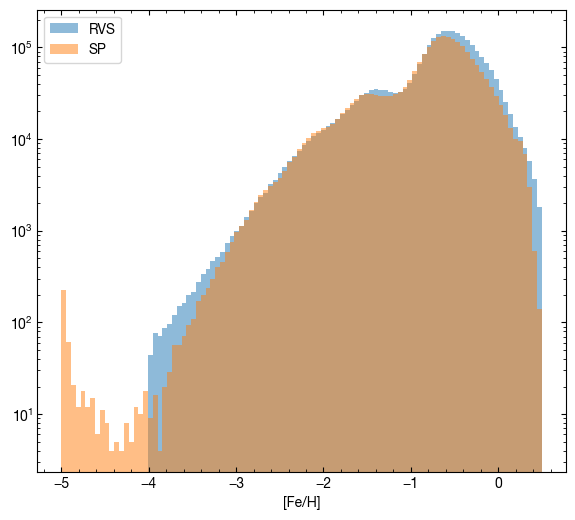

In [19]:
min_teff = 4500
max_teff = 7000
cur_sel = (main_sel & (RV_T['SURVEY'] == 'main') & (RV_T['SN_R'] > 10) &
           (RV_T['TEFF'] > min_teff) & (RV_T['TEFF'] < max_teff) &
           (RV_T['VSINI'] < 30))

plt.figure(1, figsize=(15, 6))
plt.subplot(121)
plt.hist(RV_T['FEH'][cur_sel], range=[-5, .5], label='RVS', alpha=.5, bins=100)
plt.xlabel('[Fe/H]')
cur_sel = (main_sel & (RV_T['SURVEY'] == 'main') & (RV_T['SN_R'] > 10) &
           (SP_T['BESTGRID'] != 's_rdesi1') & (SP_T['TEFF'] > min_teff) &
           (SP_T['TEFF'] < max_teff))
plt.hist(SP_T['FEH'][cur_sel], range=[-5, .5], label='SP', alpha=.5, bins=100)
plt.gca().set_yscale('log')
plt.legend()

# Individual abundances 

Here we use the abundances of Mg and Ca from the SP pipelines stored in the ELEM column 
The order of elements is  Fe, Ca, C, Mg, Si, Na, Cr, Ni, Al, and Ti. 


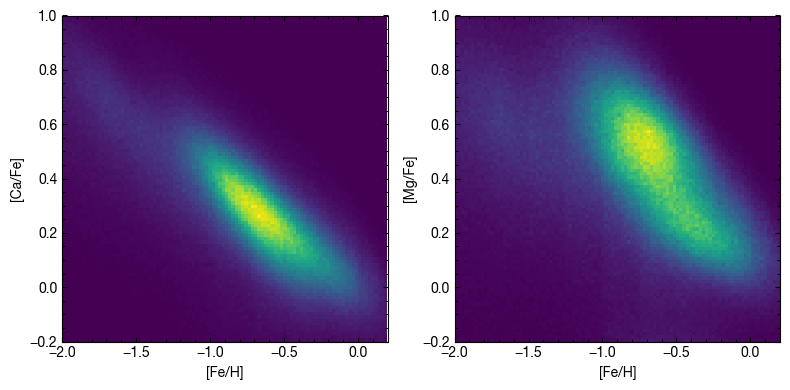

In [20]:
xind = main_sel & (RV_T['SN_R'] > 20) & (SP_T['BESTGRID'] != 's_rdesi1')
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.hist2d(SP_T['ELEM'][:, 0][xind],
           (SP_T['ELEM'][:, 1] - SP_T['ELEM'][:, 0])[xind],
           range=[[-2, .2], [-.2, 1]],
           bins=[100, 100])
plt.xlabel('[Fe/H]')
plt.ylabel('[Ca/Fe]')
plt.subplot(122)
plt.hist2d(SP_T['ELEM'][:, 0][xind],
           (SP_T['ELEM'][:, 3] - SP_T['ELEM'][:, 0])[xind],
           range=[[-2, .2], [-.2, 1]],
           bins=[100, 100])
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.tight_layout()

# Gaia HRD 

Here we just make an HRD with Gaia parallaxes: 

We note that for the DR1, the spectro-photometric distances for most stellar sources have been computed and are available as two VACs. See https://data.desi.lbl.gov/doc/releases/dr1/vac/mws-specdis and https://data.desi.lbl.gov/doc/releases/dr1/vac/mws-spdist

(15.0, -5.0)

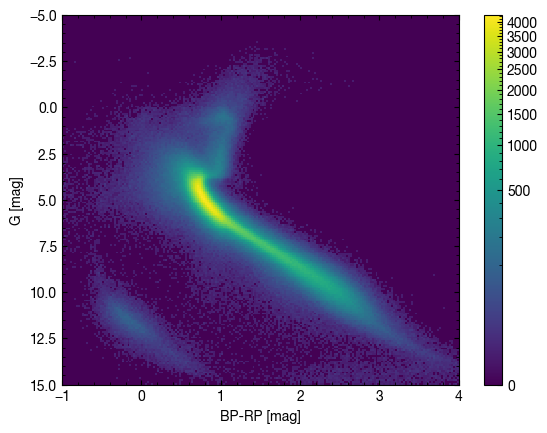

In [21]:
dist = 1. / G_T['PARALLAX']
xind = main_sel & (G_T['PARALLAX'] > 5 * G_T["PARALLAX_ERROR"])
plt.hist2d((G_T['PHOT_BP_MEAN_MAG'] -G_T['PHOT_RP_MEAN_MAG'] - 2.55 * G_T['EBV'])[xind],
           (G_T['PHOT_G_MEAN_MAG'] - (5 * np.log10(dist * 1e3) - 5))[xind],
           range=[[-1, 4], [-5, 15]],
           bins=[200, 200],
           norm=maco.PowerNorm(.3))
plt.xlabel('BP-RP [mag]')
plt.ylabel('G [mag]')
plt.colorbar()
plt.ylim(15, -5)


# Chemo-dynamics with DESI

Here we just make some basic plots using distance from Gaia parallaxes.

We note that for the DR1, the spectro-photometric distances for most stellar sources have been computed and are available as two VACs.
See 
https://data.desi.lbl.gov/doc/releases/dr1/vac/mws-specdis
and 
https://data.desi.lbl.gov/doc/releases/dr1/vac/mws-spdist


In [22]:
dist = 1. / G_T['PARALLAX']
dist[(dist < 0)] = np.nan
C = acoo.SkyCoord(ra=RV_T['TARGET_RA'] * auni.deg,
                  dec=RV_T['TARGET_DEC'] * auni.deg,
                  distance=dist * auni.kpc,
                  pm_ra_cosdec=G_T['PMRA'] * auni.mas / auni.year,
                  pm_dec=G_T['PMDEC'] * auni.mas / auni.year,
                  radial_velocity=RV_T['VRAD'])
Cg = C.transform_to(acoo.Galactocentric)
Cs = Cg.represent_as(acoo.SphericalRepresentation)
Cc = Cg.represent_as(acoo.CylindricalRepresentation)
Vphi = (Cc.differentials['s'].d_phi * Cc.rho / auni.rad).to_value(auni.km /
                                                                  auni.s)
Vpsi = (Cs.differentials['s'].d_lat * Cc.rho / auni.rad).to_value(auni.km /
                                                                  auni.s)
VR = Cs.differentials['s'].d_distance.to_value(auni.km / auni.s)
R = Cs.distance.to_value(auni.kpc)
LZ = Vphi * Cc.rho.to_value(auni.kpc)

Now we look at the Vphi vs metallicity plot that should show the disk/thick disk/splash and halo transition

Text(0, 0.5, 'V$_{\\phi}$ [km/s]')

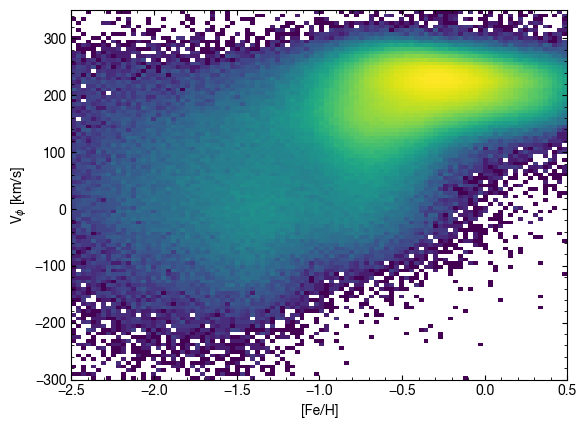

In [23]:
xind = (G_T['PARALLAX'] / G_T['PARALLAX_ERROR'] > 5) & main_sel
plt.hist2d(RV_T['FEH'][xind],
           -Vphi[xind],
           range=[[-2.5, .5], [-300, 350]],
           bins=[100, 100],
           norm=maco.LogNorm())
plt.xlabel('[Fe/H]')
plt.ylabel(r'V$_{\phi}$ [km/s]')

# Gaia phase-space spiral

Here we just reproduce the Gaia phase-space spiral from Antoja+2021 for the MWS sources with [Fe/H]>-0.2 in the VAC.

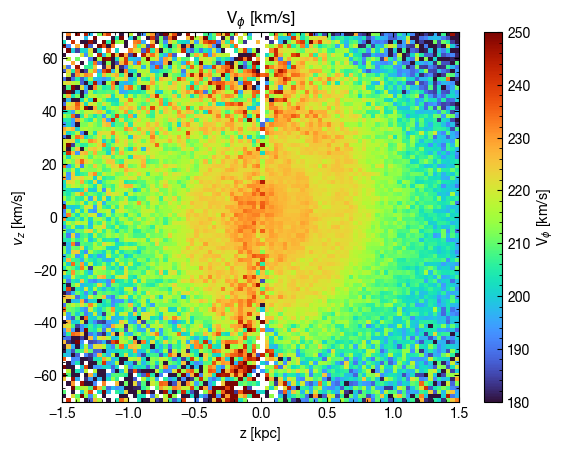

In [24]:
cur_sel = main_sel & (G_T['PARALLAX']
                      > 4 * G_T['PARALLAX_ERROR']) & (RV_T['FEH'] > -0.3)
S = scipy.stats.binned_statistic_2d(Cg.z[cur_sel],
                                    Cg.v_z[cur_sel],
                                    Vphi[cur_sel],
                                    'median',
                                    range=[[-1.5, 1.5], [-70, 70]],
                                    bins=[90, 90])

plt.imshow(-S.statistic.T,
           extent=(-1.5, 1.5, -70, 70),
           origin='lower',
           cmap='turbo',
           aspect='auto',
           vmin=180,
           vmax=250)

plt.xlabel('z [kpc]')
plt.ylabel(r'$v_z$ [km/s]')
plt.title(r'V$_\phi$ [km/s]')
plt.colorbar(label=r'V$_\phi$ [km/s]')

# Gaia-Enceladus-Sausage

Here we plot VR vs Vphi in the solar-neighbourhood to show the radially biased orbits from the GSE for the metallicity range around [Fe/H]=-1.2, The isotropic stellar halo at lower metallicities and, mostly disc + Splash at higher metallicities.

We restrict the sample to stars that are not too hot or cold.


Text(0.5, 0, 'V$_R$ [km/s]')

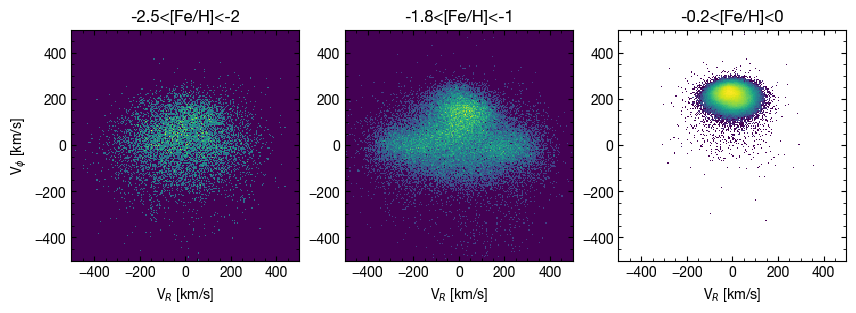

In [25]:
cur_sel0 = (main_sel & (G_T['PARALLAX'] > 5 * G_T['PARALLAX_ERROR']) &
            (RV_T['TEFF'] > 4500) & (RV_T['TEFF'] < 7000) &
            (RV_T['VSINI'] < 30))
cur_sel = cur_sel0 & (RV_T['FEH'] > -2.5) & (RV_T['FEH'] < -2)

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.hist2d(VR[cur_sel],
           -Vphi[cur_sel],
           range=[[-500, 500], [-500, 500]],
           bins=[200, 200],
           norm=maco.PowerNorm(gamma=.5))
plt.title('-2.5<[Fe/H]<-2')
plt.xlabel('V$_R$ [km/s]')
plt.ylabel(r'V$_\phi$ [km/s]')

cur_sel = cur_sel0 & (RV_T['FEH'] > -1.8) & (RV_T['FEH'] < -1.2)

plt.subplot(1, 3, 2)
plt.hist2d(VR[cur_sel],
           -Vphi[cur_sel],
           range=[[-500, 500], [-500, 500]],
           bins=[200, 200],
           norm=maco.PowerNorm(gamma=.5))
plt.title('-1.8<[Fe/H]<-1')
plt.xlabel('V$_R$ [km/s]')

cur_sel = cur_sel0 & (RV_T['FEH'] > -0.2) & (RV_T['FEH'] < -0)

plt.subplot(1, 3, 3)
plt.hist2d(VR[cur_sel],
           -Vphi[cur_sel],
           range=[[-500, 500], [-500, 500]],
           bins=[200, 200],
           norm=maco.LogNorm())
plt.title('-0.2<[Fe/H]<0')
plt.xlabel('V$_R$ [km/s]')


# GD1 

Here we plot the GD1 stars in DESI DR1. We make a simple proper motion selection using PMRA and stream coordinate phi2.

Text(0.5, 1.0, 'GD-1 stream')

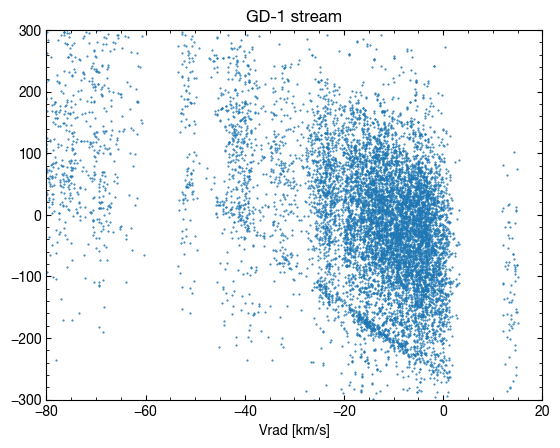

In [26]:
import gala.coordinates as gc
C=acoo.SkyCoord(ra=RV_T['TARGET_RA']*auni.deg,
                dec=RV_T['TARGET_DEC']*auni.deg)
gd1C=C.transform_to(gc.GD1Koposov10())
sel = (G_T['PMRA']<-5)&(gd1C.phi2<3*auni.deg)&(gd1C.phi2>-4*auni.deg)&(RV_T['FEH']<-1)
plt.plot(gd1C.phi1.to_value(auni.deg)[sel],RV_T['VRAD'][sel],'.',markersize=1)
plt.xlim(-80,20)
plt.ylim(-300,300)
plt.xlabel('phi1 [deg]')
plt.xlabel('Vrad [km/s]');
plt.title('GD-1 stream')


# Single epoch data

Here we look at the single epoch measurements just in the one survey/program sv3/bright

** IMPORTANT ** 
This will work if you ran the downloader script and have all the files
** IMPORTANT **


In [27]:
multi_fname = data_prefix + 'rvpix_exp-sv3-bright.fits'
# This extension contain RVS measurements
T_RV1 = atpy.Table().read(multi_fname, 'RVTAB',
                        mask_invalid=False)
# This extension contain RVS measurements
T_FM1 = atpy.Table().read(multi_fname, 'FIBERMAP',
                          mask_invalid=False)
T_G1 = atpy.Table().read(multi_fname, "GAIA",
                         mask_invalid=False)

Now we just look at one object with source_id=3698465917056207872 that is an RR Lyrae star. 
We show its radial velocity curve from DESI (from just sv3/bright) and show it after folding with the Gaia DR3 period

(0.0, 2.0)

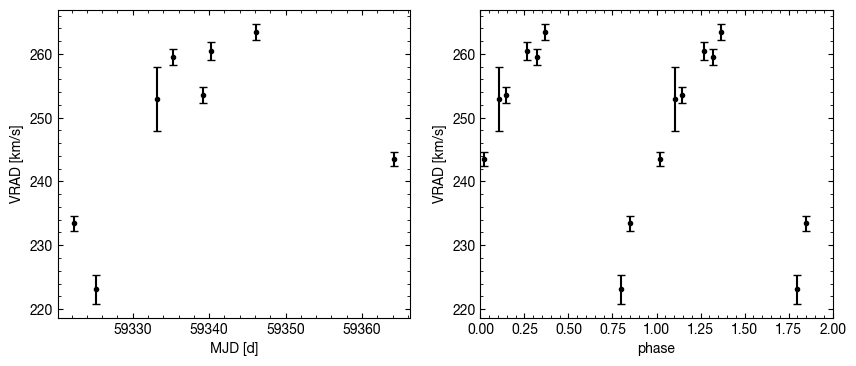

In [28]:
rrl = T_G1['SOURCE_ID'] == 3698465917056207872
rrl.sum()
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.errorbar(T_FM1['MJD'][rrl],
             T_RV1['VRAD'][rrl],
             T_RV1['VRAD_ERR'][rrl],
             fmt='k.')
plt.xlabel('MJD [d]')
plt.ylabel('VRAD [km/s]')
period = 0.49197089  # from Gaia DR3

plt.subplot(1, 2, 2)
plt.errorbar((T_FM1['MJD'][rrl] % period) / period,
             T_RV1['VRAD'][rrl],
             T_RV1['VRAD_ERR'][rrl],
             fmt='k.')
plt.errorbar((T_FM1['MJD'][rrl] % period) / period + 1,
             T_RV1['VRAD'][rrl],
             T_RV1['VRAD_ERR'][rrl],
             fmt='k.')
plt.xlabel('phase')
plt.ylabel('VRAD [km/s]')
plt.xlim(0, 2)

# Spectrum models 

Here we look at the spectral models from the RVS pipeline for one star and compare them to the observed spectra.
The model spectra are in the rvmod files. The rvmod files have the same number of rows as the rvtab files, and they are in the same order.
Importantly however, the rvtab file may have fewer rows than the original DESI file with spectra `coadd-....fits` file, because the RV pipeline does not fit *every* source observed by DESI.

In [29]:
# reading the desi coadded spectra for healpix 10813


# this this the original coadded file from DESI DR1 
spec_fname = data_prefix + 'coadd-main-bright-10813.fits'
# this this the RVS measurement table from the coadded spectra file
specrv_fname = data_prefix + 'rvtab_coadd-main-bright-10813.fits'
# this this the RVS stellar spectra file
specmodrv_fname = data_prefix + 'rvmod_coadd-main-bright-10813.fits'

SP = pyfits.open(spec_fname)

# Reading the rv table and the rvspecfit models
RV_T2 = atpy.Table().read(specrv_fname, 'RVTAB')
RVM = pyfits.open(specmodrv_fname)

# Here are the TARGETIDs of observed objects in this healpix
print(RV_T2['TARGETID'][:2]);


     TARGETID    
-----------------
39633072399846816
39633072404038155


Now we just pick up one object with TARGETID 39633086291379507 and show the observed spectra and the model spectra from the RVS pipeline.

Text(0, 0.5, 'Flux [$10^{-17}$ erg/s/cm$^2$/$\\AA$]')

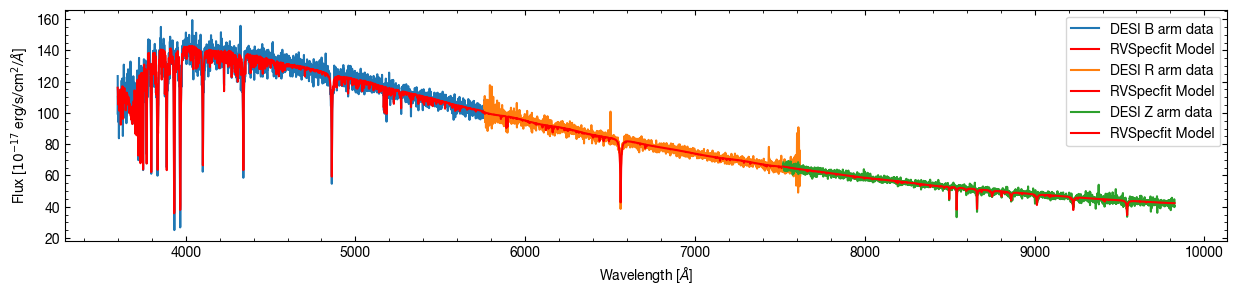

In [30]:
targetid = 39633086291379507
sel = SP['FIBERMAP'].data['TARGETID'] == targetid
rv_sel = RV_T2['TARGETID'] == targetid

plt.figure(figsize=(15, 3))
for arm in ['B', 'R', 'Z']:
    not_masked = SP[arm + '_MASK'].data[sel][0] == 0
    plt.plot(SP[arm + '_WAVELENGTH'].data[not_masked],
             SP[arm + '_FLUX'].data[sel][0][not_masked],
             label=f'DESI {arm} arm data')
    plt.plot(RVM[arm + '_WAVELENGTH'].data,
             RVM[arm + '_MODEL'].data[rv_sel][0],
             'r',
             label=f'RVSpecfit Model')
plt.legend()
plt.xlabel('Wavelength [$\AA$]')
plt.ylabel(r'Flux [$10^{-17}$ erg/s/cm$^2$/$\AA$]')

# Fetching DESI spectra for individual objects

If you want to plot desi spectra without downloading them, there is SPARCL https://astrosparcl.datalab.noirlab.edu/

but you can also use a package called `desi_retriever` https://github.com/segasai/desi_retriever/

If you install that package, you can easily fetch the spectrum and the RVSpecFit model for every source in the VAC, using 
the survey, program, healpix and TARGETID (or alternatively gaia_id)

The cells at the bottom will *only* work if you have desi_retriever installed.
When you run this, it will fetch the spectrum from the NERSC cluster.

https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/main/bright/108/10813/coadd-main-bright-10813.fits


Text(0, 0.5, 'Flux [$10^{-17}$ erg/s/cm$^2$/$\\AA$]')

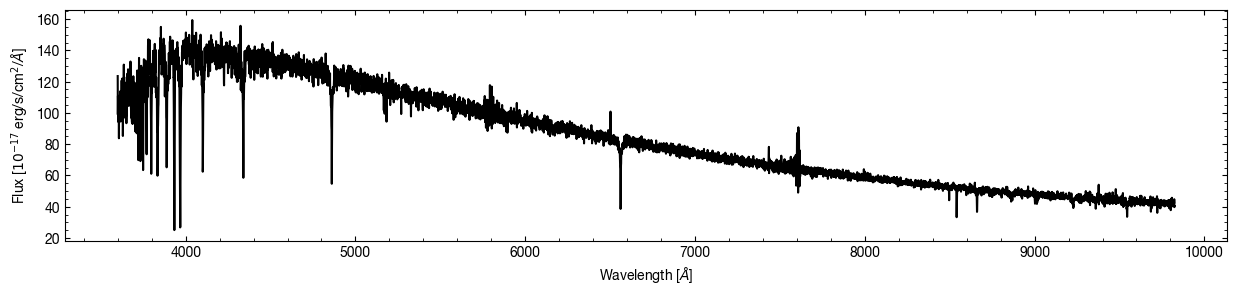

In [31]:
# Let's plot the spectrum of the same object we previously plotted
# We need survey, program, healpix and targetid

from desi_retriever.dr1 import get_specs, get_rvspec_models

SP_ret1 = get_specs(survey='main',
                    program='bright',
                    hpx=10813,
                    targetid=39633086291379507,
                    mask=True)[0]
# This now the dictionary with keys like b_wavelength, b_flux etc

plt.figure(figsize=(15, 3))
for arm in ['b', 'r', 'z']:
    not_masked = SP_ret1[arm + '_mask'] == 0

    plt.plot(SP_ret1[arm + '_wavelength'][not_masked],
             SP_ret1[arm + '_flux'][not_masked], 'k')
plt.xlabel('Wavelength [$\AA$]')
plt.ylabel(r'Flux [$10^{-17}$ erg/s/cm$^2$/$\AA$]')

The models can be retrieved using get_rvspec_models() function

https://data.desi.lbl.gov/public/dr1/vac/dr1/mws/iron/v1.0/rv_output/240520//healpix/main/bright/108/10813/rvmod_coadd-main-bright-10813.fits


Text(0, 0.5, 'Flux [$10^{-17}$ erg/s/cm$^2$/$\\AA$]')

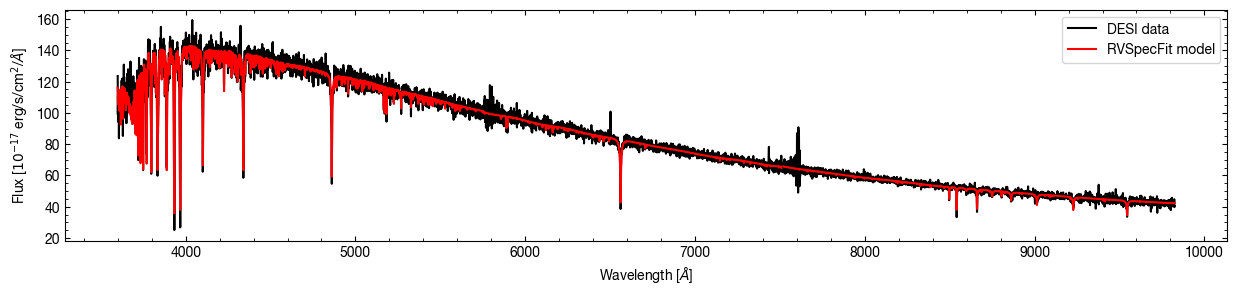

In [32]:
# Fetching the RVSpecFit models
SPM_ret1 = get_rvspec_models(survey='main',
                             program='bright',
                             hpx=10813,
                             targetid=39633086291379507)[0]
plt.figure(figsize=(15, 3))
for arm in ['b', 'r', 'z']:
    not_masked = SP_ret1[arm + '_mask'] == 0
    plt.plot(SP_ret1[arm + '_wavelength'][not_masked],
             SP_ret1[arm + '_flux'][not_masked],
             'k',
             label=f'DESI data')
    plt.plot(SPM_ret1[arm + '_wavelength'],
             SPM_ret1[arm + '_model'],
             'red',
             label=f'RVSpecFit model')
    if arm == 'b': plt.legend()
plt.xlabel('Wavelength [$\AA$]')
plt.ylabel(r'Flux [$10^{-17}$ erg/s/cm$^2$/$\AA$]')

# Fetching the spectrum by Gaia DR3 SOURCE_ID

desi_retriever can in principle be also used to fetch just by Gaia source_id.
To run this, the code will download a local copy of a small table to speed up future searches.

https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/main/bright/227/22752/coadd-main-bright-22752.fits
https://data.desi.lbl.gov/public/dr1/vac/dr1/mws/iron/v1.0/rv_output/240520//healpix/main/bright/227/22752/rvmod_coadd-main-bright-22752.fits


Text(0, 0.5, 'Flux [$10^{-17}$ erg/s/cm$^2$/$\\AA$]')

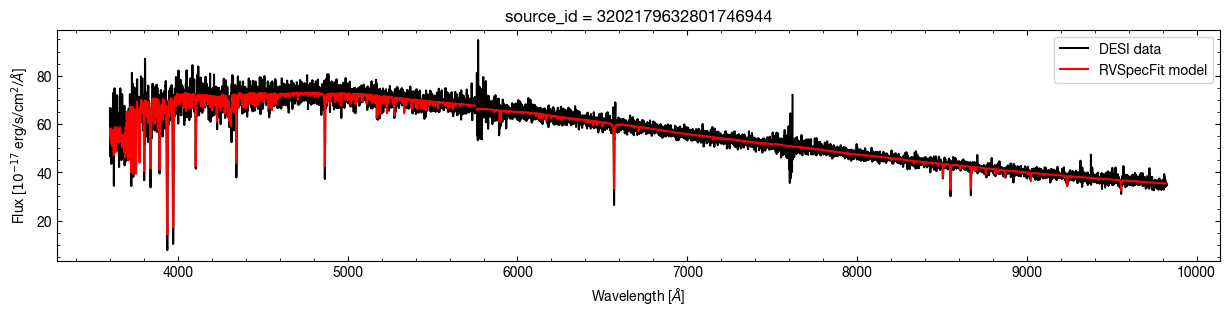

In [33]:
my_source_id = 3202179632801746944
# obtaining spectra by Gaia source_id
SP_ret2 = get_specs(gaia_edr3_source_id=my_source_id, mask=True)[0]
SPM_ret2 = get_rvspec_models(gaia_edr3_source_id=my_source_id)[0]
plt.figure(figsize=(15, 3))
for arm in ['b', 'r', 'z']:
    not_masked = SP_ret2[arm + '_mask'] == 0
    plt.plot(SP_ret2[arm + '_wavelength'][not_masked],
             SP_ret2[arm + '_flux'][not_masked],
             'k',
             label=f'DESI data')
    plt.plot(SPM_ret2[arm + '_wavelength'],
             SPM_ret2[arm + '_model'],
             'red',
             label=f'RVSpecFit model')
    if arm == 'b': plt.legend()
plt.title('source_id = %d' % my_source_id)
plt.xlabel('Wavelength [$\AA$]')
plt.ylabel(r'Flux [$10^{-17}$ erg/s/cm$^2$/$\AA$]')

# Using Sparcl to fetch spectra

If you have sparcl installed you can fetch spectra by targetid easily from the database hosted by NOIRLab
Using SPARCL protocol https://gitlab.com/nsf-noirlab/csdc/datalab/sparcl/sparclclient

Note that these are 'stitched' spectra from all 3 arms. I.e. those are not quite the spectra used for the stellar fitting. (but should be close)

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


Text(0, 0.5, 'Flux [$10^{-17}$ erg/s/cm$^2$/$\\AA$]')

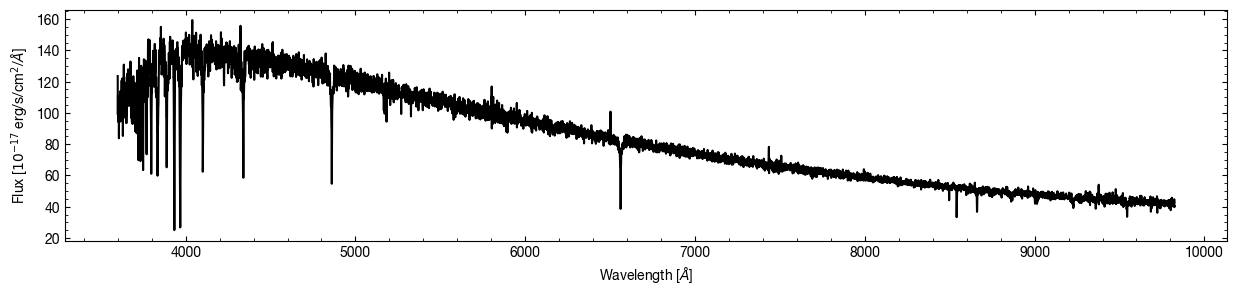

In [34]:
from sparcl.client import SparclClient

client = SparclClient()
res = client.retrieve_by_specid([39633086291379507],
                                dataset_list=['DESI-DR1'],
                                include=['flux', 'wavelength',
                                         'mask']).records[0]
plt.figure(figsize=(15, 3))
plt.plot(res['wavelength'][res['mask'] == 0], res['flux'][res['mask'] == 0],
         'k')
plt.xlabel('Wavelength [$\AA$]')
plt.ylabel(r'Flux [$10^{-17}$ erg/s/cm$^2$/$\AA$]')